## Importing libraries

In [4]:
import os
import h5py
import numpy as np
import json
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display, clear_output
from sklearn.metrics import classification_report, confusion_matrix

from keras import optimizers
from keras.applications.vgg16 import VGG16
from keras.models import Sequential, load_model, Model
from keras.layers import Conv2D, MaxPooling2D, ZeroPadding2D, Activation, Dropout, Flatten, Dense, Input
from keras.regularizers import l2, l1
from tensorflow.keras.utils import to_categorical
from keras.preprocessing.image import  array_to_img, img_to_array, load_img
from keras.callbacks import ModelCheckpoint, History
from keras import backend as K
from tensorflow.keras.utils import get_file
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential, load_model

from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, Input
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import SGD
import json


%matplotlib inline
sns.set_style('whitegrid')

## Function for model evaluation

In [5]:
def evaluate_categorical_model(model, directory, labels):
    datagen = ImageDataGenerator(rescale=1./255)  

    generator = datagen.flow_from_directory(directory,
                                target_size=(img_height, img_width),
                                batch_size=8,
                                class_mode='categorical',
                                shuffle=False)
    
    predictions = model.predict(generator, len(labels))
    pred_labels = np.argmax(predictions, axis=1)

    print ('')
    print (classification_report(validation_labels, pred_labels))
    print ('')
    cm = confusion_matrix(validation_labels, pred_labels)
    sns.heatmap(cm, annot=True, fmt='g');

## Function for vizulization

In [6]:
def plot_metrics(hist, stop=50):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
                            
    axes = axes.flatten()

    axes[0].plot(range(stop), hist['accuracy'], label='Training', color='#FF533D')
    axes[0].plot(range(stop), hist['val_accuracy'], label='Validation', color='#03507E')
    axes[0].set_title('Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend(loc='lower right')
                             
    axes[1].plot(range(stop), hist['loss'], label='Training', color='#FF533D')
    axes[1].plot(range(stop), hist['val_loss'], label='Validation', color='#03507E')
    axes[1].set_title('Loss')
    axes[1].set_ylabel('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(loc='upper right')
                             
    plt.tight_layout();
    
    print("Best Model:") 
    print_best_model_results(hist)

## Function to print best model

In [7]:
def print_best_model_results(model_hist):
    best_epoch = np.argmax(model_hist['val_accuracy'])
    print('epoch:', best_epoch+1, \
    ', val_accuracy:', model_hist['val_accuracy'][best_epoch], \
    ', val_loss:', model_hist['val_loss'][best_epoch])

## Path to save a model

In [8]:
# path to the model weights file
location = 'data3a'
top_model_weights_path=location+'/top_model_weights.weights.h5' # will be saved into when we create our model
# model_path = location + '/initial_data2_model.h5'
fine_tuned_model_path = location+'/ft_model.keras'

# dimensions of our images
img_width, img_height = 256, 256

train_data_dir = location+'/training'
validation_data_dir = location+'/validation'

nb_train_samples = 960


train_samples = [len(os.listdir(train_data_dir+'/'+i)) for i in sorted(os.listdir(train_data_dir))]
validation_samples = [len(os.listdir(validation_data_dir+'/'+i)) for i in sorted(os.listdir(validation_data_dir))]
nb_validation_samples = 160

nb_epoch = 50
batch_size = 32

## Creating bottleneck feature(vgg16)

In [9]:
def save_bottleneck_features(location):
    datagen = ImageDataGenerator(rescale=1./255)
    
    model = VGG16(include_top=False, weights='imagenet')
    
    # Training data generator
    generator = datagen.flow_from_directory(
        train_data_dir, 
        target_size=(img_width, img_height), 
        class_mode=None, 
        shuffle=False
    )
    
    # Predict and save bottleneck features for training data
    bottleneck_features_train = model.predict(generator, steps=nb_train_samples // batch_size, verbose=1)
    np.save(location + '/bottleneck_features_train.npy', bottleneck_features_train)
    
    # Validation data generator
    generator = datagen.flow_from_directory(
        validation_data_dir, 
        target_size=(img_width, img_height), 
        class_mode=None, 
        shuffle=False
    )
    
    # Predict and save bottleneck features for validation data
    bottleneck_features_validation = model.predict(generator, steps=nb_validation_samples // batch_size, verbose=1)
    np.save(location + '/bottleneck_features_validation.npy', bottleneck_features_validation)




In [32]:
# Call the function with location as an argument
save_bottleneck_features(location)


Found 979 images belonging to 3 classes.
30/30 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step
Found 171 images belonging to 3 classes.
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step


## model 1

In [ ]:
def train_categorical_model():
    # Loaded the bottleneck features directly from the file paths without using open()
    train_data = np.load(location + '/bottleneck_features_train.npy')
    train_labels = np.array([0]*(273) + [1]*(310) + [2]*(377))

    train_labels = to_categorical(train_labels)

    validation_data = np.load(location + '/bottleneck_features_validation.npy')
    validation_labels = np.array([0]*(46) + [1]*(51) + [2]*(63))

    validation_labels = to_categorical(validation_labels)
    
    model = Sequential()
    model.add(Flatten(input_shape=train_data.shape[1:]))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(3, activation='softmax'))

    model.compile(optimizers.SGD(learning_rate=0.0001, momentum=0.9), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])

    checkpoint = ModelCheckpoint(top_model_weights_path, 
                                 monitor='val_accuracy',  
                                 verbose=1, 
                                 save_best_only=True, 
                                 save_weights_only=True, 
                                 mode='auto')

    fit = model.fit(train_data, train_labels,
                    epochs=nb_epoch, 
                    batch_size=batch_size,
                    validation_data=(validation_data, validation_labels),
                    callbacks=[checkpoint])
    
    with open(location + '/top_history.txt', 'w') as f:
        json.dump(fit.history, f)
    
    return model, fit.history



In [27]:
# Call the function
d3_model2, d3_hist2 = train_categorical_model()

Epoch 1/50


c:\Users\pbans\OneDrive\Desktop\CD2\.conda\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4297 - loss: 6.0393
Epoch 1: val_accuracy improved from -inf to 0.60625, saving model to data3a/top_model_weights.weights.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.4345 - loss: 6.0109 - val_accuracy: 0.6062 - val_loss: 4.8303
Epoch 2/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6831 - loss: 4.4937
Epoch 2: val_accuracy did not improve from 0.60625
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6838 - loss: 4.4811 - val_accuracy: 0.5938 - val_loss: 4.0967
Epoch 3/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7570 - loss: 3.7003
Epoch 3: val_accuracy did not improve from 0.60625
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7582 - loss: 3.6898 - val_accuracy: 0.5938 - val_loss: 3.6315
Epoch 4/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8149 - loss: 3.1477
Epoch 4: val_accuracy improved from 0.60625 to 0.63125, saving model to data3a/top_model_weights.weights.h5
30/30 ━━

Best Model:
epoch: 28 , val_accuracy: 0.6312500238418579 , val_loss: 0.8301805257797241


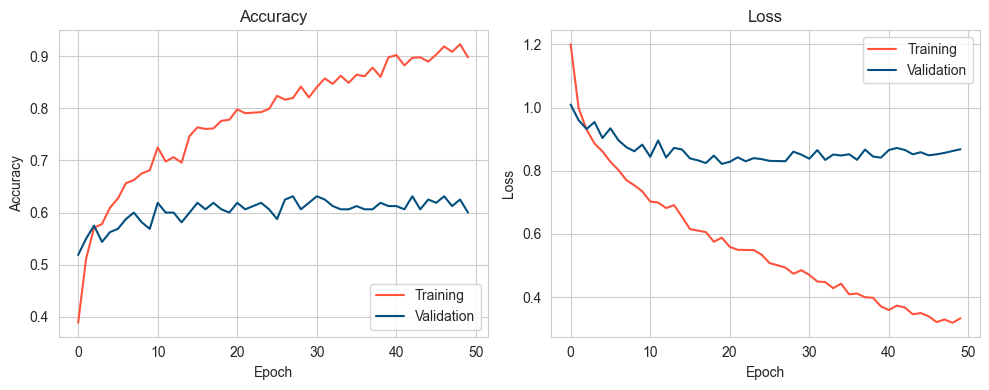

In [83]:
plot_metrics(d3_hist2)


## model with L2

In [15]:
def train_categorical_model():
    # Load the bottleneck features directly from the file paths without using open()
    train_data = np.load(location + '/bottleneck_features_train.npy')
    train_labels = np.array([0]*(273) + [1]*(310) + [2]*(377))

    train_labels = to_categorical(train_labels)

    validation_data = np.load(location + '/bottleneck_features_validation.npy')
    validation_labels = np.array([0]*(46) + [1]*(51) + [2]*(63))

    validation_labels = to_categorical(validation_labels)
    
    model = Sequential()
    model.add(Flatten(input_shape=train_data.shape[1:]))
    model.add(Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
    model.add(Dropout(0.5))
    model.add(Dense(3, activation='softmax', kernel_regularizer=regularizers.l2(0.01)))

    model.compile(optimizers.Adam(learning_rate=0.0001), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])

    checkpoint = ModelCheckpoint(top_model_weights_path, 
                                 monitor='val_accuracy',  # Fix monitor key
                                 verbose=1, 
                                 save_best_only=True, 
                                 save_weights_only=True, 
                                 mode='auto')

    fit = model.fit(train_data, train_labels,
                    epochs=nb_epoch, 
                    batch_size=batch_size,
                    validation_data=(validation_data, validation_labels),
                    callbacks=[checkpoint])
    
    with open(location + '/top_history.txt', 'w') as f:
        json.dump(fit.history, f)
    
    return model, fit.history




In [16]:
from tensorflow.keras import regularizers

# Call the function
d3_model_l2, d3_hist_l2 = train_categorical_model()

Epoch 1/50


c:\Users\pbans\OneDrive\Desktop\CD2\.conda\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3948 - loss: 6.2031
Epoch 1: val_accuracy improved from -inf to 0.57500, saving model to data3a/top_model_weights.weights.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.3997 - loss: 6.1679 - val_accuracy: 0.5750 - val_loss: 4.7521
Epoch 2/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6587 - loss: 4.4192
Epoch 2: val_accuracy did not improve from 0.57500
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6596 - loss: 4.4048 - val_accuracy: 0.5562 - val_loss: 3.9449
Epoch 3/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7574 - loss: 3.5384
Epoch 3: val_accuracy improved from 0.57500 to 0.63750, saving model to data3a/top_model_weights.weights.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.7579 - loss: 3.5290 - val_accuracy: 0.6375 - val_loss: 3.3613
Epoch 4/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8156 - loss: 2.9295
Epoch 4: val_accuracy did not improve from 0.63750
30/30 ━━

Best Model:
epoch: 3 , val_accuracy: 0.637499988079071 , val_loss: 3.361344814300537


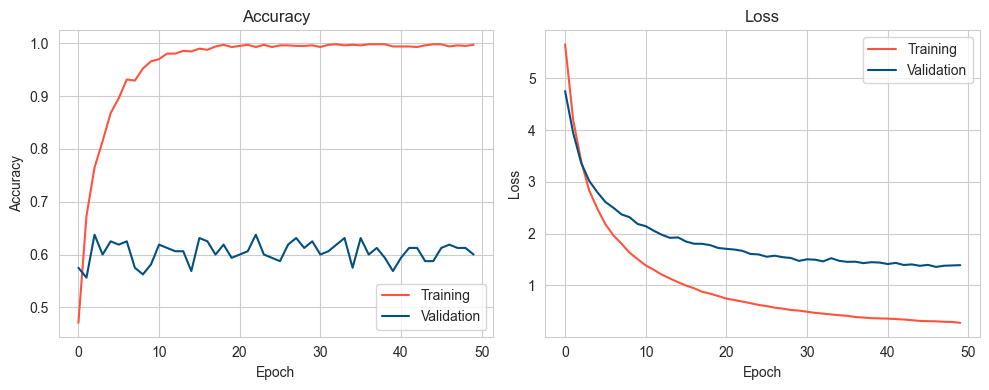

In [17]:
plot_metrics(d3_hist_l2)


## Finetuned model (ft_d3_model)

In [ ]:
def finetune_categorical_model():
    # Load base VGG16 model without the top layers
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
    print("Base model loaded.")
    
    # Add custom top model
    top_model = Sequential()
    top_model.add(Flatten(input_shape=base_model.output_shape[1:]))
    top_model.add(Dense(256, activation='relu'))
    top_model.add(Dropout(0.5))
    top_model.add(Dense(3, activation='softmax'))  # For 3 classes

    # Attach top model to base model
    model = Model(inputs=base_model.input, outputs=top_model(base_model.output))

    # Freeze some layers of base model for fine-tuning
    for layer in base_model.layers[:15]:  # Fine-tune after layer 15
        layer.trainable = False
    
    # Compile the model
    model.compile(
        loss='categorical_crossentropy',
        optimizer=SGD(learning_rate=1e-4, momentum=0.9),
        metrics=['accuracy']
    )

    # Data augmentation for training
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        zoom_range=0.2,
        shear_range=0.2,
        horizontal_flip=True
    )
    
    # Data generator for validation
    validation_datagen = ImageDataGenerator(rescale=1./255)

    # Create data generators
    train_generator = train_datagen.flow_from_directory(
        train_data_dir,
        target_size=(256, 256),
        batch_size=batch_size,
        class_mode='categorical'
    )

    validation_generator = validation_datagen.flow_from_directory(
        validation_data_dir,
        target_size=(256, 256),
        batch_size=batch_size,
        class_mode='categorical'
    )

    # Save best model during training
    checkpoint = ModelCheckpoint(
        filepath=fine_tuned_model_path,
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True
    )

    # Train the model
    fit = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // batch_size,
        callbacks=[checkpoint]
    )

    # Save training history
    with open(location + '/ft_history.txt', 'w') as f:
        json.dump(fit.history, f)

    # Save the full model
    model.save(location + '/fine_tuned_final_model.h5')
    print("Model saved successfully.")
    
    return model, fit.history

# Call the function
ft_d3_model, ft_d3_hist = finetune_categorical_model()


Base model loaded.
Found 979 images belonging to 3 classes.
Found 171 images belonging to 3 classes.
Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3566 - loss: 1.4470
Epoch 1: val_accuracy improved from -inf to 0.43750, saving model to data3a/ft_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 144s 5s/step - accuracy: 0.3570 - loss: 1.4428 - val_accuracy: 0.4375 - val_loss: 1.0877
Epoch 2/50
 1/30 ━━━━━━━━━━━━━━━━━━━━ 6:32 14s/step - accuracy: 0.3438 - loss: 1.2253

c:\Users\pbans\OneDrive\Desktop\CD2\.conda\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)



Epoch 2: val_accuracy improved from 0.43750 to 0.54545, saving model to data3a/ft_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 213ms/step - accuracy: 0.3438 - loss: 1.2253 - val_accuracy: 0.5455 - val_loss: 0.9241
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4627 - loss: 1.0671
Epoch 3: val_accuracy improved from 0.54545 to 0.55000, saving model to data3a/ft_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 156s 5s/step - accuracy: 0.4627 - loss: 1.0664 - val_accuracy: 0.5500 - val_loss: 0.9871
Epoch 4/50
 1/30 ━━━━━━━━━━━━━━━━━━━━ 1:48 4s/step - accuracy: 0.3438 - loss: 1.1315
Epoch 4: val_accuracy did not improve from 0.55000
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.3438 - loss: 1.1315 - val_accuracy: 0.5455 - val_loss: 0.9120
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4941 - loss: 0.9717
Epoch 5: val_accuracy improved from 0.55000 to 0.55625, saving model to data3a/ft_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 145s 5s/step - accuracy: 0.4945 - loss

Model saved successfully.


In [22]:
ft_d3_model = load_model(r'C:\Users\pbans\Desktop\CD_2\data3a\ft_model.keras') # without regularization, first run


In [35]:
heatmap_labels = ['minor', 'moderate', 'severe']

In [20]:
validation_labels = np.array([0] * validation_samples[0] + 
                             [1] * validation_samples[1] +
                             [2] * validation_samples[2])

Found 171 images belonging to 3 classes.


c:\Users\pbans\OneDrive\Desktop\CD2\.conda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 490ms/step

              precision    recall  f1-score   support

           0       0.70      0.58      0.64        48
           1       0.48      0.56      0.52        55
           2       0.79      0.76      0.78        68

    accuracy                           0.65       171
   macro avg       0.65      0.64      0.64       171
weighted avg       0.66      0.65      0.65       171




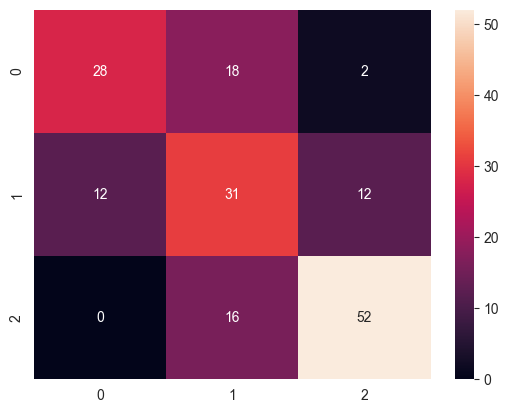

In [33]:
cm = evaluate_categorical_model(ft_d3_model, validation_data_dir, validation_labels) 


Best Model:
epoch: 32 , val_accuracy: 0.9090909361839294 , val_loss: 0.5154315233230591


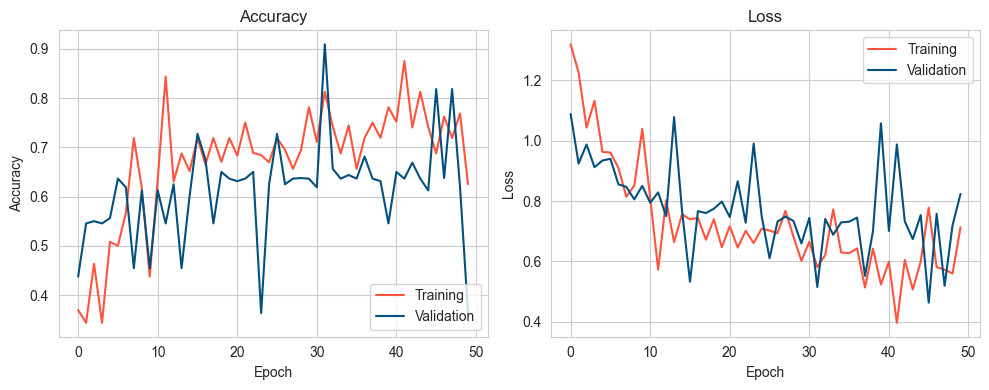

In [ ]:
# plotting acc and loss of finetuned model
plot_metrics(ft_d3_hist)


## creating pipeline 4

In [24]:
import requests
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

def pipe4(image_url, model):
    # Download the image
    response = requests.get(image_url, stream=True)
    
    if response.status_code == 200 and 'image' in response.headers['Content-Type']:
        with open('save.jpg', 'wb') as f:
            f.write(response.content)
        
        # Load and preprocess the image
        img = load_img('save.jpg', target_size=(256, 256))
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape) / 255.0
        
        # Make a prediction
        pred = model.predict(x)
        pred_labels = np.argmax(pred, axis=1)
        
        # Map prediction to class
        d = {0: 'minor', 1: 'moderate', 2: 'severe'}
        print("Validating location of damage....Result:", d.get(pred_labels[0], 'Unknown'))
        print("Severity assessment complete.")
    else:
        print("Error: Could not download or identify the image. Please check the URL.")

# Usage
pipe4('https://drndata.com/wp-content/uploads/2016/03/car.jpg', ft_d3_model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
Validating location of damage....Result: moderate
Severity assessment complete.


In [25]:
pipe4('https://www.nerdwallet.com/blog/wp-content/uploads/2015/12/exterior-car-damage-384x233.jpg', ft_d3_model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Validating location of damage....Result: minor
Severity assessment complete.
